In [2]:
# import libraries
import pandas as pd
import seaborn as sns

import matplotlib 
import matplotlib.pyplot as plt
plt.style.use('default') # 'ggplot'
from matplotlib.pyplot import figure

matplotlib.rcParams['figure.figsize'] = (12,8) # adjusts the config of the plots 


# Import and Assess Data sets

In [2]:
pd.set_option('display.max_rows', None)

### Assess borrower profile data

In [3]:
## import file 1
profileData = pd.read_csv('borrower_profiles.csv')
profileData.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [5]:
profileData.info(verbose = True, memory_usage = 'deep', show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   borrower_id            500 non-null    object
 1   age                    500 non-null    int64 
 2   state                  500 non-null    object
 3   education_level        500 non-null    object
 4   employment_status      500 non-null    object
 5   years_employed         500 non-null    int64 
 6   annual_income          500 non-null    int64 
 7   credit_score           500 non-null    int64 
 8   home_ownership         500 non-null    object
 9   dependents             500 non-null    int64 
 10  existing_monthly_debt  500 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 159.4 KB


In [3]:
profileData.describe()

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.986000,10.854000,64471.484000,704.952000,1.356000,1585.166000
std,13.539736,9.301706,28959.837645,97.339157,1.252358,1089.979915
min,22.000000,0.000000,12549.000000,528.000000,0.000000,124.000000
25%,33.000000,3.000000,42968.250000,617.750000,0.000000,788.750000
50%,45.000000,8.000000,59282.500000,708.000000,1.000000,1312.000000
75%,57.000000,17.000000,79780.500000,794.250000,2.000000,2131.750000
max,68.000000,35.000000,157047.000000,850.000000,4.000000,6130.000000


In [6]:
profileData.nunique()

borrower_id              500
age                       47
state                     30
education_level            5
employment_status          5
years_employed            36
annual_income            499
credit_score             251
home_ownership             3
dependents                 5
existing_monthly_debt    461
dtype: int64

In [11]:
profileData.apply(pd.unique)

borrower_id              [BRW-0001, BRW-0002, BRW-0003, BRW-0004, BRW-0...
age                      [62, 24, 50, 43, 46, 40, 35, 30, 39, 54, 32, 4...
state                    [CT, CO, NC, TX, NY, OR, GA, KY, UT, WA, FL, A...
education_level          [High School, Bachelor, Doctorate, Master, Ass...
employment_status        [Self-Employed, Full-Time, Contract, Part-Time...
years_employed           [6, 4, 22, 19, 18, 8, 5, 14, 15, 2, 0, 9, 28, ...
annual_income            [31020, 40188, 41014, 35036, 44528, 157047, 84...
credit_score             [596, 543, 611, 701, 715, 749, 576, 563, 643, ...
home_ownership                                       [Rent, Own, Mortgage]
dependents                                                 [1, 2, 0, 3, 4]
existing_monthly_debt    [892, 869, 1806, 928, 608, 3076, 1682, 939, 64...
dtype: object

In [19]:
profileData.employment_status.value_counts(normalize = True)
# half of data set are full time workers, evenly split amongst other cats

employment_status
Full-Time        0.504
Self-Employed    0.180
Part-Time        0.110
Contract         0.108
Retired          0.098
Name: proportion, dtype: float64

In [24]:
#profileData.age.value_counts(normalize = True) # even
#profileData.state.value_counts(normalize = True) # even
#profileData.education_level.value_counts(normalize = True) # Few doctorates
#profileData.education_level.value_counts() # Few doctorates < 4%)
profileData.home_ownership.value_counts(normalize = True) # even 

home_ownership
Mortgage    0.432
Rent        0.354
Own         0.214
Name: proportion, dtype: float64

<Axes: ylabel='Frequency'>

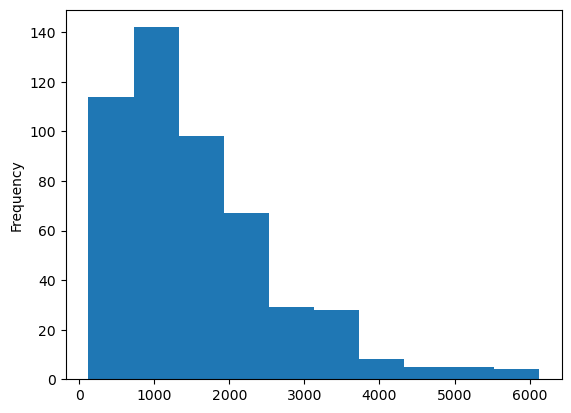

In [30]:
profileData['existing_monthly_debt'].plot.hist()

In [31]:
profileData.groupby('home_ownership')['existing_monthly_debt'].mean()

home_ownership
Mortgage    1559.314815
Own         1503.869159
Rent        1665.858757
Name: existing_monthly_debt, dtype: float64

<Axes: xlabel='age', ylabel='existing_monthly_debt'>

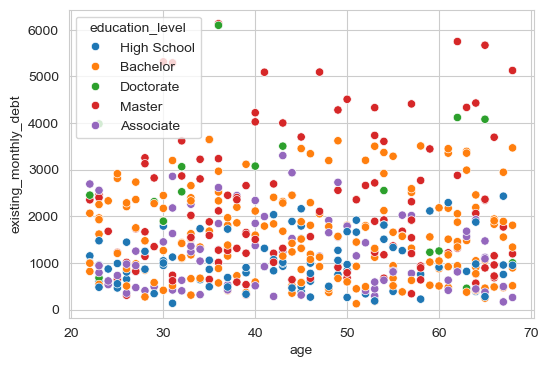

In [70]:
# Assess trends by groups using hue
sns.set_style('whitegrid')
fig,ax = plt.subplots(figsize = (6, 4))
   
sns.scatterplot(data = profileData, x = 'age', y = 'existing_monthly_debt', 
                hue = 'education_level', 
                #hue = 'credit_score'
                #hue = 'dependents'
                )

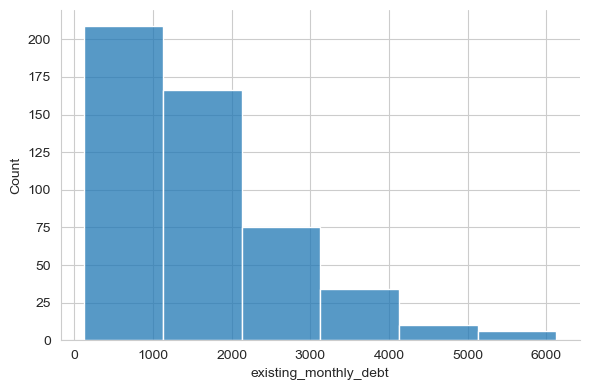

In [66]:
# Assess data distribution
g = sns.displot(kind = 'hist', data = profileData,
                #x = 'age', # fairly even distribution
                #x = 'credit_score', # there are a LOT of 800+ credit scores!
                #x = 'annual_income', # largest group between 40-60k. Right tail
                #x = 'education_level', # Low # of doctorates, High Bachelors, Other classifications about equal
                #x = 'home_ownership',
                x = 'existing_monthly_debt', # Smallest values are Highest counts, left skewed, right tail
                bins = 6,
               height = 4, aspect = 1.5)
#for ax in g.axes.flat:
#    ax.set(title = 'Assess data distribution')

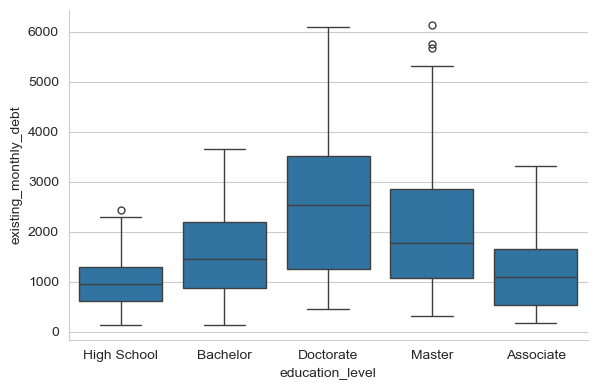

In [67]:
# Assess range of data per grouping
sns.catplot(kind = 'box', data = profileData,
            x = 'education_level', y = 'existing_monthly_debt',
            height = 4, aspect = 1.5)

### Asssess Application Data

In [30]:
# import file 2
appData = pd.read_csv('loan_applications.csv')
appData.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [39]:
appData.info(verbose = True, memory_usage = 'deep', show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   loan_id           601 non-null    object 
 1   borrower_id       601 non-null    object 
 2   application_date  601 non-null    object 
 3   loan_purpose      601 non-null    object 
 4   loan_amount       601 non-null    float64
 5   term_months       601 non-null    int64  
 6   interest_rate     601 non-null    float64
 7   monthly_payment   601 non-null    float64
 8   dti_ratio         601 non-null    float64
 9   loan_status       601 non-null    object 
 10  days_delinquent   601 non-null    int64  
 11  defaulted         601 non-null    int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 202.9 KB


In [40]:
appData.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amount,601.0,22148.252912,13215.261422,2000.00,10900.00,20400.00,32700.00,49800.00
term_months,601.0,36.539101,16.898192,12.00,24.00,36.00,48.00,60.00
interest_rate,601.0,10.641331,2.251153,5.86,8.94,10.54,12.33,15.86
monthly_payment,601.0,948.337654,864.959543,44.14,359.86,684.87,1165.20,4262.69
dti_ratio,601.0,49.680699,24.113652,7.60,32.20,48.10,62.40,177.40
days_delinquent,601.0,27.036606,47.802845,0.00,0.00,0.00,30.00,180.00
defaulted,601.0,0.242928,0.429209,0.00,0.00,0.00,0.00,1.00


In [47]:
# assess app date values to determine why they are classified as objects vs dates... 
appData.application_date.value_counts()

application_date
2024-06-01    6
2025-02-27    6
2025-05-18    5
2024-04-05    4
2025-01-19    4
             ..
2024-05-26    1
2025-01-21    1
2024-03-31    1
2024-02-16    1
2024-05-03    1
Name: count, Length: 369, dtype: int64

In [31]:
# convert application date to date time
appData[['application_date']] = appData[['application_date']].apply(pd.to_datetime)

In [49]:
appData.head()
appData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   loan_id           601 non-null    object        
 1   borrower_id       601 non-null    object        
 2   application_date  601 non-null    datetime64[ns]
 3   loan_purpose      601 non-null    object        
 4   loan_amount       601 non-null    float64       
 5   term_months       601 non-null    int64         
 6   interest_rate     601 non-null    float64       
 7   monthly_payment   601 non-null    float64       
 8   dti_ratio         601 non-null    float64       
 9   loan_status       601 non-null    object        
 10  days_delinquent   601 non-null    int64         
 11  defaulted         601 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 56.5+ KB


In [182]:
appData.nunique()

loan_id             601
borrower_id         500
application_date    369
loan_purpose         10
loan_amount         341
term_months           5
interest_rate       426
monthly_payment     600
dti_ratio           413
loan_status           4
days_delinquent      94
defaulted             2
dtype: int64

In [183]:
appData.apply(pd.unique)

loan_id             [LN-00001, LN-00002, LN-00003, LN-00004, LN-00...
borrower_id         [BRW-0001, BRW-0002, BRW-0003, BRW-0004, BRW-0...
application_date    [2024-01-08, 2024-08-13, 2025-06-28, 2025-05-1...
loan_purpose        [Vacation, Major Purchase, Moving, Auto Loan, ...
loan_amount         [16100.0, 5600.0, 44700.0, 9200.0, 11200.0, 28...
term_months                                      [36, 48, 12, 60, 24]
interest_rate       [13.05, 14.21, 12.37, 11.18, 9.66, 13.07, 10.2...
monthly_payment     [542.86, 153.62, 1492.59, 238.58, 359.61, 768....
dti_ratio           [55.5, 40.4, 70.5, 59.8, 44.1, 37.1, 49.9, 38....
loan_status                        [Paid Off, Default, Current, Late]
days_delinquent     [0, 138, 34, 38, 43, 105, 63, 15, 170, 168, 13...
defaulted                                                      [0, 1]
dtype: object

In [51]:
appData.isnull().sum()

loan_id             0
borrower_id         0
application_date    0
loan_purpose        0
loan_amount         0
term_months         0
interest_rate       0
monthly_payment     0
dti_ratio           0
loan_status         0
days_delinquent     0
defaulted           0
dtype: int64

In [53]:
appData.duplicated(keep = False)

0      False
1      False
2      False
3      False
4      False
       ...  
596    False
597    False
598    False
599    False
600    False
Length: 601, dtype: bool

# Join tables

In [32]:
#profileData = profileData.set_index('borrower_id')
profileData = profileData.reset_index()

In [33]:
joinedData = profileData.merge(right = appData, on = 'borrower_id', suffixes = ('_1', '_2'),
                             how = 'left')

In [63]:
joinedData.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [64]:
# save progress
joinedData.to_pickle('joinedData.pkl')

# Analysis

In [6]:
myData = pd.read_pickle('joinedData.pkl')
myData.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


### Create bins for credit score ranges and DTI ranges

In [7]:
# bin ranges from experian [https://www.experian.com/blogs/ask-experian/infographic-what-are-the-different-scoring-ranges/]
#myData['cred_score_bin'] = pd.cut(myData.credit_score, bins = [0, 579, 669, 739, 799, 850], labels = ['poor (0-579)', 'fair (580-669)', 'good (670-739)', 'very good (740-799)', 'exceptional (800+)'])

# bin ranges per instructions
myData['cred_score_bin'] = pd.cut(myData.credit_score, bins = [520, 599, 649, 699, 749, 850], labels = ['520-599', '600-649', '650-699', '700-749', '750+'])

In [8]:
# bin ranges from investopedia [https://www.investopedia.com/terms/d/dti.asp]
# original -- too many categories
#myData['dti_bin'] = pd.cut(myData.dti_ratio, bins = [0, 25, 35, 45, 50, 75, 100, 150, 200], 
#                           labels = ['0-25%', '26-35%', '36-45%', '46-50%', '51-75%', '76-100%', '100-150%', '151-200%'])

myData['dti_bin'] = pd.cut(myData.dti_ratio, bins = [0, 25, 35, 45, 50, 200], 
                           labels = ['0-25%', '26-35%', '36-45%', '46-50%', '>51%'])

In [9]:
# bins include 2 yr cutoff (instead of 1 yr) because of question related to 2 yrs
myData['yrs_emp_bin'] = pd.cut(myData['years_employed'], bins = [0, 2, 5, 10, 40], labels = ['<2 yr', '2-5 yrs', '6-10 yrs', '10+ yrs'])
myData.yrs_emp_bin.value_counts()

yrs_emp_bin
10+ yrs     261
6-10 yrs    110
<2 yr        96
2-5 yrs      95
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

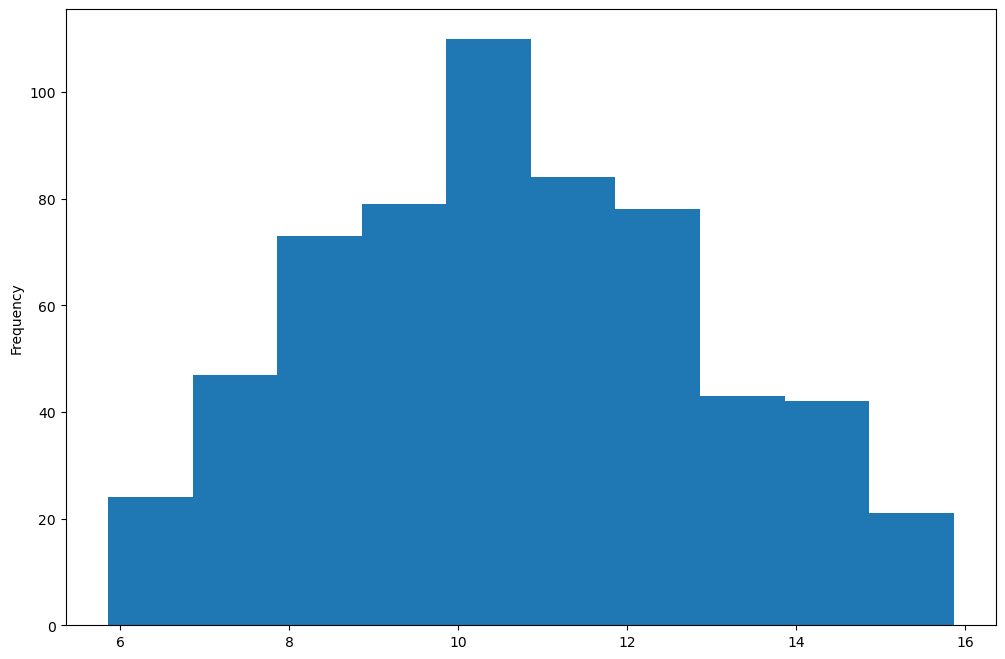

In [10]:
# Assess interest rate data
myData['interest_rate'].describe()
myData['interest_rate'].plot.hist()

In [11]:
myData['int_rate_bin'] = pd.cut(myData['interest_rate'], bins = 10)
myData.int_rate_bin.value_counts()

int_rate_bin
(9.86, 10.86]     110
(10.86, 11.86]     82
(8.86, 9.86]       80
(11.86, 12.86]     79
(7.86, 8.86]       72
(6.86, 7.86]       48
(12.86, 13.86]     42
(13.86, 14.86]     42
(5.85, 6.86]       25
(14.86, 15.86]     21
Name: count, dtype: int64

In [12]:
myData.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,cred_score_bin,dti_bin,yrs_emp_bin,int_rate_bin
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,13.05,542.86,55.5,Paid Off,0,0,520-599,>51%,6-10 yrs,"(12.86, 13.86]"
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,14.21,153.62,40.4,Default,138,1,520-599,36-45%,6-10 yrs,"(13.86, 14.86]"
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,12.37,1492.59,70.5,Paid Off,0,0,520-599,>51%,2-5 yrs,"(11.86, 12.86]"
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,11.18,238.58,59.8,Default,34,1,600-649,>51%,10+ yrs,"(10.86, 11.86]"
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,9.66,359.61,44.1,Current,0,0,700-749,36-45%,10+ yrs,"(8.86, 9.86]"


In [13]:
# Assess # of values per bin
#myData.cred_score_bin.value_counts()
myData.dti_bin.value_counts()

dti_bin
>51%      270
26-35%    102
36-45%     90
0-25%      79
46-50%     60
Name: count, dtype: int64

# Segment Analysis

In [3]:
myData = pd.read_pickle('joinedData.pkl')
myData.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


### Calculate Overall Default Rate

In [14]:
myData.defaulted.mean()

np.float64(0.24292845257903495)

### Default by credit score range

In [15]:
myData.groupby('cred_score_bin', observed = False)[['defaulted']].mean()
# note -- ranges per experian change the distribution of default rate

,defaulted
cred_score_bin,
520-599,0.491379
600-649,0.290323
650-699,0.280000
700-749,0.162791
750+,0.116883


<Axes: title={'center': 'Count of Borrowers'}, xlabel='cred_score_bin'>

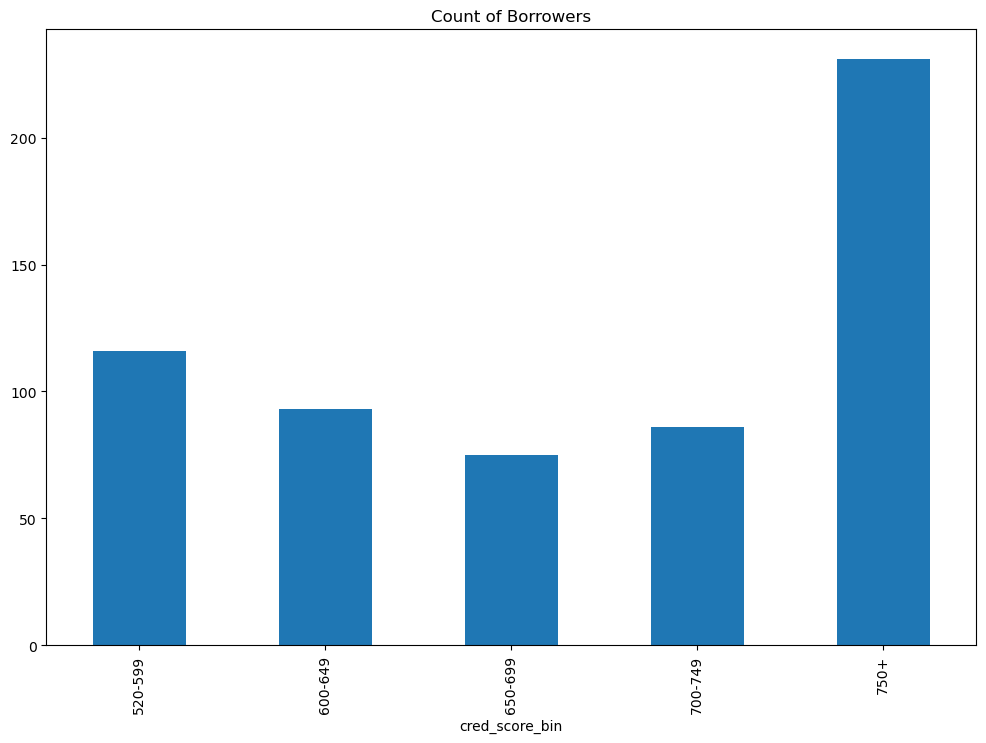

In [17]:
# Count # of borrowers per bin
#fig,ax = plt.subplots(figsize = (6, 4))

myData.groupby('cred_score_bin', observed = False)[['borrower_id']].count() \
    .plot.bar(title = 'Count of Borrowers', legend = False)

In [67]:
# get counts and loan amounts 
myData.groupby(['cred_score_bin', 'defaulted'], observed = False).agg({'defaulted':'count','loan_amount': 'sum'}).unstack()

defaulted     loan_amount           
defaulted              0   1           0          1
cred_score_bin                                     
520-599               59  57   1347300.0  1376600.0
600-649               66  27   1260900.0   524400.0
650-699               54  21   1152600.0   549900.0
700-749               72  14   1656700.0   264900.0
750+                 204  27   4598300.0   579500.0

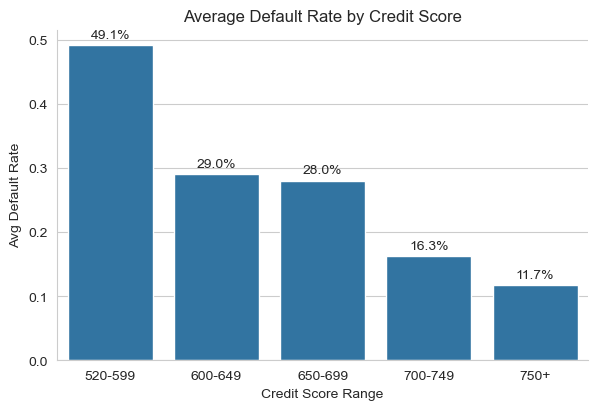

In [160]:
sns.set_style('whitegrid')

g = sns.catplot(data = myData.groupby('cred_score_bin', observed = False)[['defaulted']].mean(), 
                kind = 'bar', x = 'cred_score_bin', y = 'defaulted', 
                #hue = 'cred_score_bin',
                height = 4, aspect =  1.5)

for ax in g.axes.flat:
    ax.set(title = 'Average Default Rate by Credit Score',
           ylabel = 'Avg Default Rate', xlabel = 'Credit Score Range')

    # add labels for each bar
    for container in ax.containers:
        labels = [f'{v.get_height():.1%}' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

g.savefig('avg_def_by_cred_score.png')

### DTI vs Default status

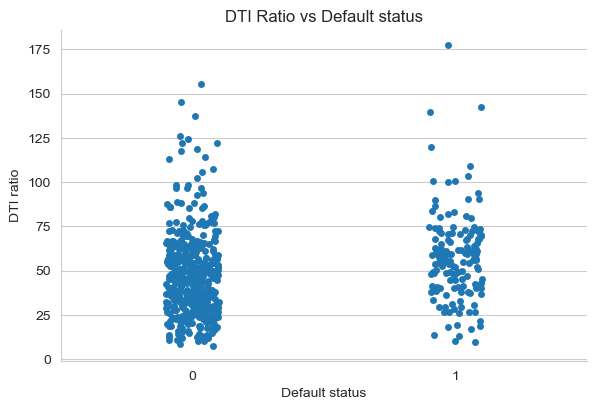

In [91]:
# Note -- used strip plot to jitter points and make them more visible
g = sns.catplot(data = myData, kind = 'strip', x = 'defaulted', y = 'dti_ratio', 
               height = 4, aspect = 1.5)
                    
for ax in g.axes.flat:
    ax.set(title = 'DTI Ratio vs Default status', 
           ylabel = 'DTI ratio', xlabel = 'Default status')

### Default rate by DTI bin

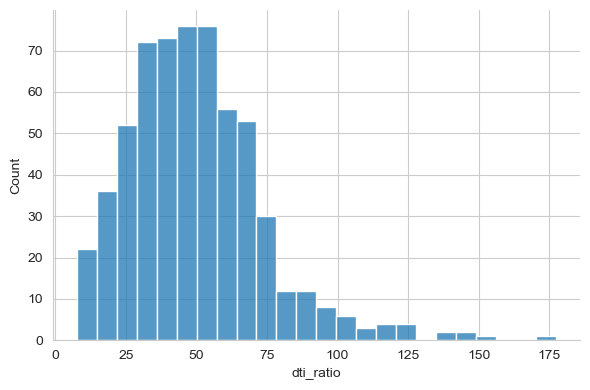

In [92]:
# assess distribution of DTI data
sns.displot(data = myData, kind = 'hist', x = 'dti_ratio', height = 4, aspect = 1.5)

In [237]:
# calculate default rate by DTI bin
myData.groupby('dti_bin', observed = False)[['defaulted']].mean()

,defaulted
dti_bin,
0-25%,0.113924
26-35%,0.127451
36-45%,0.211111
46-50%,0.200000
>51%,0.344444


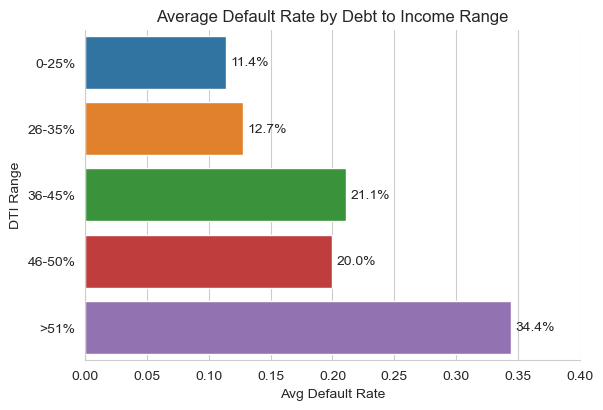

In [87]:
# create visual for default rate by DTI 
sns.set_style('whitegrid')
g = sns.catplot(data = myData.groupby('dti_bin', observed = False)[['defaulted']].mean(), 
            kind = 'bar', y = 'dti_bin', x = 'defaulted', 
                #hue = 'dti_bin',
               height = 4, aspect = 1.5)

for ax in g.axes.flat:
    ax.set(title = 'Average Default Rate by Debt to Income Range',
           xlabel = 'Avg Default Rate', ylabel = 'DTI Range',
           xlim = (0.00, 0.40))
    #ax.tick_params('x', labelrotation = 45)

    for container in ax.containers:
        labels = [f'{v.get_width():.1%}' for v in container]
        ax.bar_label(container, labels=labels, padding=3)    

g.savefig('avg_def_by_dti.png')


In [239]:
# get counts and loan amounts to assess prospective business lost based on DTI group cutoff
myData.groupby(['dti_bin', 'defaulted'], observed = False).agg({'borrower_id':'count','loan_amount': 'sum'}).unstack()

borrower_id     loan_amount           
defaulted           0   1           0          1
dti_bin                                         
0-25%              70   9   1038800.0   118500.0
26-35%             89  13   1619700.0   194300.0
36-45%             71  19   1632500.0   328800.0
46-50%             48  12   1021500.0   212200.0
>51%              177  93   4703300.0  2441500.0

### Assess default rate over combinations of Credit Score & DTI

In [51]:
# Drill into default rate by DTI bin & cred_score_bins
myData.pivot_table(index = 'cred_score_bin', columns = 'dti_bin', values = 'defaulted', aggfunc = ['mean', 'count'], observed = False)

mean                                         count         \
dti_bin            0-25%    26-35%    36-45%    46-50%      >51% 0-25% 26-35%   
cred_score_bin                                                                  
520-599         0.100000  0.307692  0.384615  0.500000  0.594595    10     13   
600-649         0.133333  0.200000  0.235294  0.272727  0.428571    15     15   
650-699         0.222222  0.071429  0.300000  0.272727  0.387097     9     14   
700-749         0.076923  0.105263  0.187500  0.000000  0.275862    13     19   
750+            0.093750  0.073171  0.117647  0.130435  0.138614    32     41   

                                   
dti_bin        36-45% 46-50% >51%  
cred_score_bin                     
520-599            13      6   74  
600-649            17     11   35  
650-699            10     11   31  
700-749            16      9   29  
750+               34     23  101

In [245]:
#dtiGroups = myData['dti_bin'].drop_duplicates().sort_values('dti_bin', ascending = True).tolist()
myData['dti_bin'].drop_duplicates().tolist()

['>51%', '36-45%', '46-50%', '0-25%', '26-35%']

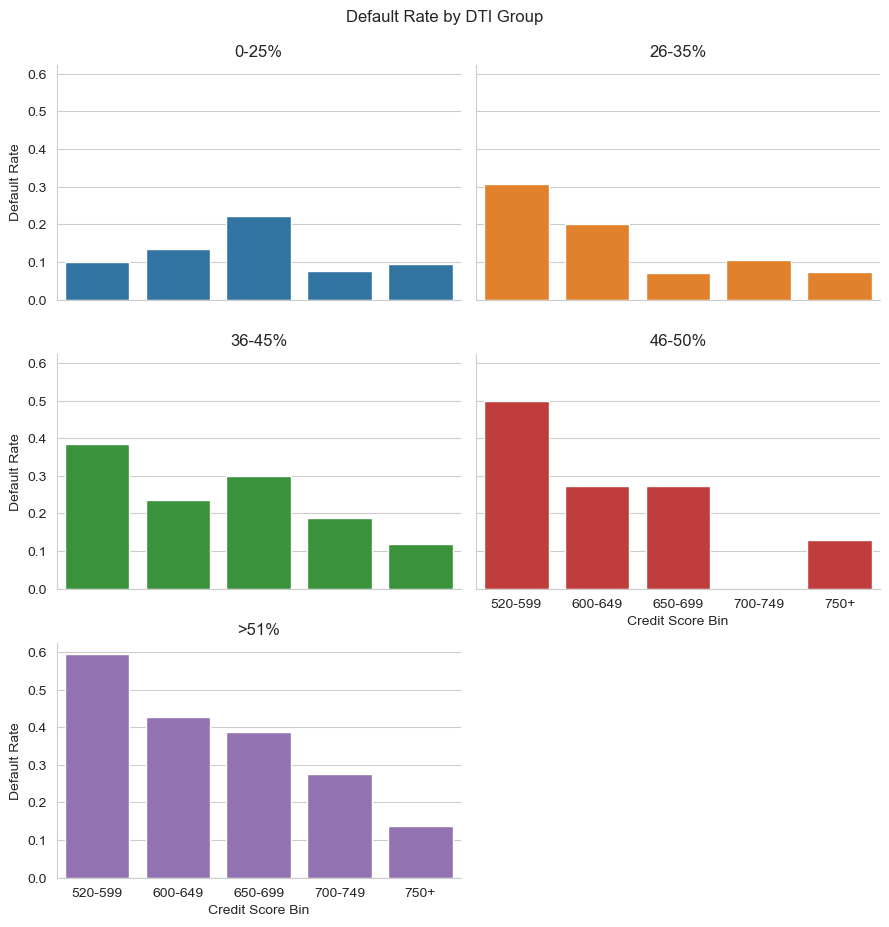

In [246]:
dti_order = ['0-25%', '26-35%', '36-45%', '46-50%', '>51%']
g = sns.catplot(data = myData.groupby(['cred_score_bin', 'dti_bin'], observed = False)[['defaulted']].mean(),
                kind = 'bar', x = 'cred_score_bin', y = 'defaulted', 
                col = 'dti_bin', col_wrap = 2, col_order = dti_order,
                hue = 'dti_bin', legend = False, height = 3, aspect = 1.5)
g.fig.suptitle('Default Rate by DTI Group', y = 1.025)

  
for ax, title in zip(g.axes.flat, dti_order):
    ax.set_title(title)
    ax.set_ylabel('Default Rate')
    ax.set_xlabel('Credit Score Bin')

### Default rate by employment status

In [247]:
# calc default rate
myData.groupby('employment_status', observed = False)[['defaulted']].mean().sort_values('defaulted', ascending = False) 
# fairly even (all between 22-28%)

,defaulted
employment_status,
Part-Time,0.276923
Self-Employed,0.247619
Full-Time,0.239344
Retired,0.233333
Contract,0.227273


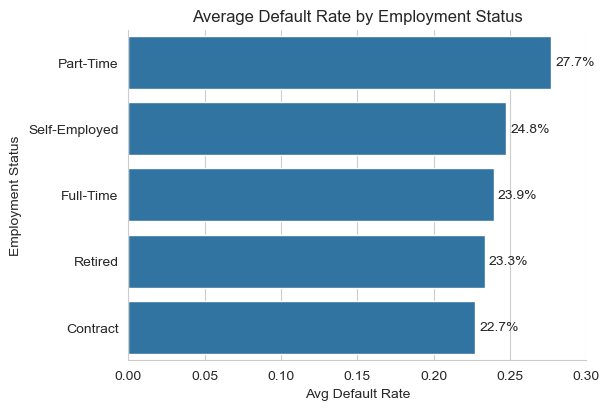

In [159]:
# create visual of rates by status
sns.set_style('whitegrid')

g = sns.catplot(myData.groupby('employment_status', observed = False)[['defaulted']]
    .mean().sort_values('defaulted', ascending = False), 
                kind = 'bar', y = 'employment_status', x = 'defaulted', 
                #hue = 'employment_status',
                height = 4, aspect = 1.5)

for ax in g.axes.flat:
    ax.set(title = 'Average Default Rate by Employment Status',
           xlabel = 'Avg Default Rate', ylabel = 'Employment Status',
          xlim = (0.00, 0.30))
    #ax.tick_params('x', labelrotation = 45)

    for container in ax.containers:
        labels = [f'{v.get_width():.1%}' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

g.savefig('avg_def_by_emp_status.png')

In [98]:
myData.pivot_table(index = 'employment_status', columns = 'cred_score_bin', values = 'defaulted', aggfunc = ['mean', 'count'], observed = False).round(3)

mean                                  count          \
cred_score_bin    520-599 600-649 650-699 700-749   750+ 520-599 600-649   
employment_status                                                          
Contract            0.467   0.333   0.000   0.182  0.095      15      12   
Full-Time           0.444   0.309   0.412   0.143  0.100      54      55   
Part-Time           0.583   0.200   0.286   0.364  0.056      12      10   
Retired             0.462   0.250   0.000   0.250  0.143      13       8   
Self-Employed       0.591   0.250   0.176   0.000  0.182      22       8   

                                        
cred_score_bin    650-699 700-749 750+  
employment_status                       
Contract                7      11   21  
Full-Time              34      42  120  
Part-Time              14      11   18  
Retired                 3       8   28  
Self-Employed          17      14   44

### Default rate by years employed

In [54]:
myData.groupby('yrs_emp_bin', observed = False)[['defaulted']].mean() 

,defaulted
yrs_emp_bin,
<2 yr,0.322917
2-5 yrs,0.115789
6-10 yrs,0.300000
10+ yrs,0.229885


In [60]:
avgDefYrsEmp = myData.groupby(['years_employed'], observed = False)[['defaulted']].mean() # fairly even (all between 22-28%)
avgDefYrsEmp.head()

,defaulted
years_employed,
0,0.282051
1,0.400000
2,0.254902
3,0.166667
4,0.037037


In [55]:
#myData.groupby(['years_employed'], observed = False)[['defaulted']].mean() # fairly even (all between 22-28%)

# add count of records per group to assess relevancy
defRateByYearsEmp = (myData.groupby('years_employed', observed = False)
    .agg({'defaulted': 'mean', 'borrower_id': 'count'})
    .rename(columns = {'defaulted': 'Avg_Default_Rate', 'borrower_id' : 'Count'})
) 



In [56]:
defRateByYearsEmp.head()

,Avg_Default_Rate,Count
years_employed,,
0,0.282051,39
1,0.400000,45
2,0.254902,51
3,0.166667,36
4,0.037037,27


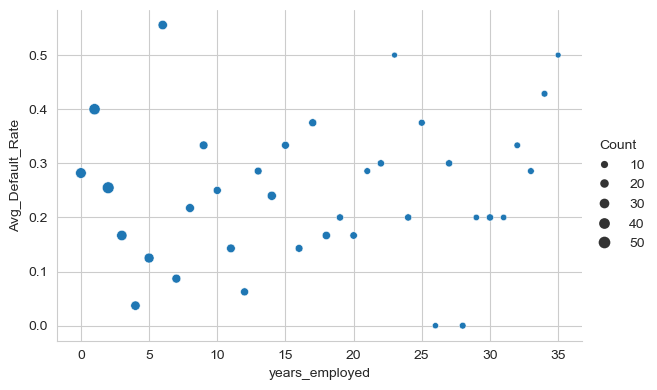

In [89]:
# visualization showing size of group per year employed and avg default rate
sns.relplot(data = defRateByYearsEmp, kind = 'scatter', size = 'Count', x = 'years_employed',
            y = 'Avg_Default_Rate', height = 4, aspect = 1.5)

In [58]:
myData.pivot_table(index = 'yrs_emp_bin',  values = 'defaulted', aggfunc = ['mean', 'count'], observed = False).round(3)

,mean,count
,defaulted,defaulted
yrs_emp_bin,,
<2 yr,0.323,96
2-5 yrs,0.116,95
6-10 yrs,0.300,110
10+ yrs,0.230,261


In [97]:
myData.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,cred_score_bin,dti_bin,int_rate_bin,yrs_emp_bin
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,13.05,542.86,55.5,Paid Off,0,0,520-599,>51%,"(12.86, 13.86]",6-10 yrs
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,14.21,153.62,40.4,Default,138,1,520-599,36-45%,"(13.86, 14.86]",6-10 yrs
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,12.37,1492.59,70.5,Paid Off,0,0,520-599,>51%,"(11.86, 12.86]",2-5 yrs
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,11.18,238.58,59.8,Default,34,1,600-649,>51%,"(10.86, 11.86]",10+ yrs
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,9.66,359.61,44.1,Current,0,0,700-749,36-45%,"(8.86, 9.86]",10+ yrs


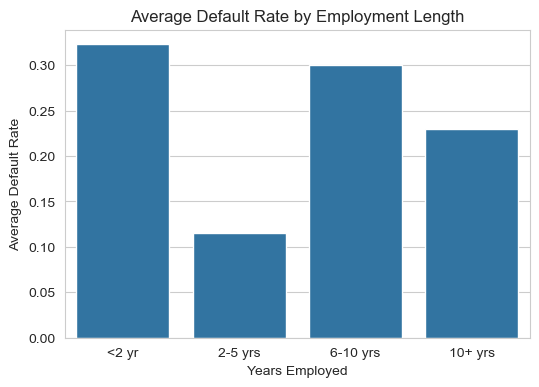

In [158]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize = (6, 4))

ax = sns.barplot(data = myData.groupby('yrs_emp_bin', observed = False)[['defaulted']].mean(),
                 x = 'yrs_emp_bin', y = 'defaulted', 
                 #hue = 'yrs_emp_bin'
                )

ax.set(title = 'Average Default Rate by Employment Length',
       xlabel = 'Years Employed', ylabel = 'Average Default Rate')


fig.savefig('avg_def_by_emp_length.png')

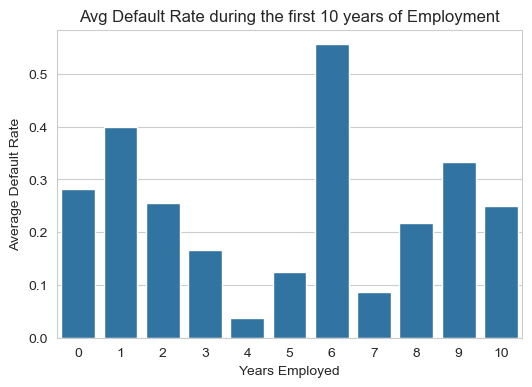

In [93]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize = (6, 4))

ax = sns.barplot(data = avgDefYrsEmp.query('years_employed <= 10'),
                x = 'years_employed', y = 'defaulted', #hue = 'yrs_emp_bin'
                )

ax.set(title = 'Avg Default Rate during the first 10 years of Employment',
       xlabel = 'Years Employed', ylabel = 'Average Default Rate')


fig.savefig('avg_def_by_yrs_emp_less_than_10.png')

#### Default Rate by Years Employed groups

In [125]:
myData.pivot_table(index = 'yrs_emp_bin', columns = 'cred_score_bin', values = 'defaulted', aggfunc = ['mean', 'count'], observed = False).round(3)

mean                                  count                  \
cred_score_bin 520-599 600-649 650-699 700-749   750+ 520-599 600-649 650-699   
yrs_emp_bin                                                                     
<1 yr            0.750   0.600   0.750   0.333  0.167       4      10       4   
1-5 yrs          0.300   0.261   0.062   0.143  0.119      20      23      16   
6-10 yrs         0.531   0.500   0.385   0.333  0.067      32       8      13   
10+ yrs          0.549   0.208   0.270   0.086  0.100      51      48      37   

                             
cred_score_bin 700-749 750+  
yrs_emp_bin                  
<1 yr                9   18  
1-5 yrs             28   59  
6-10 yrs            12   45  
10+ yrs             35   90

In [153]:
# same query, using updated groups (<2 and 2-5 yrs in lieu of 1 yr)
myData.pivot_table(index = 'yrs_emp_bin', columns = 'cred_score_bin', 
                   values = 'defaulted', aggfunc = ['mean', 'count'], observed = False).round(3)

mean                                  count                  \
cred_score_bin 520-599 600-649 650-699 700-749   750+ 520-599 600-649 650-699   
yrs_emp_bin                                                                     
<2 yr            0.500   0.476   0.375   0.263  0.194      12      21       8   
2-5 yrs          0.250   0.167   0.083   0.111  0.073      12      12      12   
6-10 yrs         0.531   0.500   0.385   0.333  0.067      32       8      13   
10+ yrs          0.549   0.208   0.270   0.086  0.100      51      48      37   

                             
cred_score_bin 700-749 750+  
yrs_emp_bin                  
<2 yr               19   36  
2-5 yrs             18   41  
6-10 yrs            12   45  
10+ yrs             35   90

#### Default Rate based on 2 year employment length

In [25]:
# add column to assign 2 year group
myData['less2yrs'] = myData.apply(lambda x: 1 if x.years_employed <= 2 else 0, axis = 1)
myData.head()
    


,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,cred_score_bin,dti_bin,yrs_emp_bin,less2yrs
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,13.05,542.86,55.5,Paid Off,0,0,520-599,>51%,6-10 yrs,0
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,14.21,153.62,40.4,Default,138,1,520-599,36-45%,6-10 yrs,0
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,12.37,1492.59,70.5,Paid Off,0,0,520-599,>51%,1-5 yrs,0
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,11.18,238.58,59.8,Default,34,1,600-649,>51%,10+ yrs,0
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,9.66,359.61,44.1,Current,0,0,700-749,36-45%,10+ yrs,0


In [22]:
myData.groupby('less2yrs')['defaulted'].mean()

less2yrs
0    0.223176
1    0.311111
Name: defaulted, dtype: float64

### Default rate by loan purpose

In [83]:
(myData.groupby('loan_purpose', observed = False)[['defaulted']]
    .mean()
    .sort_values('defaulted', ascending = False)
    .mul(100)
    .round(1)) 
# fairly even across all cats


,defaulted
loan_purpose,
Wedding,32.1
Home Improvement,28.6
Auto Loan,27.1
Business Loan,24.1
Education,22.6
Vacation,22.6
Major Purchase,22.1
Debt Consolidation,21.6
Moving,21.4


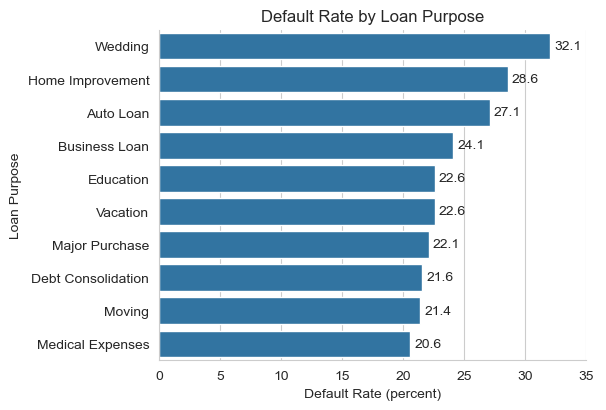

In [157]:
# create visual
sns.set_style('whitegrid')
g = sns.catplot(data = myData.groupby('loan_purpose', observed = False)[['defaulted']]
    .mean().sort_values('defaulted', ascending = False).mul(100).round(1),   # multiply results by 100 and use 1 decimal for output display
                y = 'loan_purpose', kind = 'bar', 
                #hue = 'loan_purpose',
                x = 'defaulted', height = 4, aspect = 1.5)
for ax in g.axes.flat:
    ax.set(title = 'Default Rate by Loan Purpose', 
           xlabel = 'Default Rate (percent)', ylabel = 'Loan Purpose',
           xlim = (0,35))
    #ax.tick_params('x', labelrotation = 90)

    for container in ax.containers:
        #labels = [f'{v.get_width():.1%}' for v in container] # width for hbar plots
        ax.bar_label(container, fmt = '%.1f', padding=3)   

g.savefig('avg_def_by_purpose.png')

### Compare default rate with loan purpose AND credit score groups

In [100]:
myData.pivot_table(index = 'loan_purpose', columns = 'cred_score_bin', values = 'defaulted', aggfunc = ['mean', 'count'], observed = False).round(3)

mean                                  count          \
cred_score_bin     520-599 600-649 650-699 700-749   750+ 520-599 600-649   
loan_purpose                                                                
Auto Loan            0.545   0.250   0.286   0.167  0.176      11      12   
Business Loan        0.500   0.214   0.250   0.222  0.143      10      14   
Debt Consolidation   0.333   0.167   0.111   0.500  0.174       9       6   
Education            0.444   0.222   0.000   0.000  0.125      18       9   
Home Improvement     0.545   0.300   0.417   0.273  0.115      11      10   
Major Purchase       0.529   0.400   0.000   0.154  0.091      17       5   
Medical Expenses     0.500   0.222   0.400   0.083  0.071      14       9   
Moving               0.000   0.364   0.500   0.125  0.083       3      11   
Vacation             0.500   0.500   0.167   0.125  0.100      12       6   
Wedding              0.636   0.364   0.800   0.000  0.125      11      11   

                                         
cred_score_bin     650-699 700-749 750+  
loan_purpose                             
Auto Loan                7      12   17  
Business Loan            4       9   21  
Debt Consolidation       9       4   23  
Education                6       4   16  
Home Improvement        12      11   26  
Major Purchase          11      13   22  
Medical Expenses         5      12   28  
Moving                  10       8   24  
Vacation                 6       8   30  
Wedding                  5       5   24

### Default rate by Interest rate

In [39]:
myData.groupby('int_rate_bin', observed = False)['defaulted'].mean()

int_rate_bin
(5.85, 6.86]      0.240000
(6.86, 7.86]      0.166667
(7.86, 8.86]      0.097222
(8.86, 9.86]      0.225000
(9.86, 10.86]     0.200000
(10.86, 11.86]    0.219512
(11.86, 12.86]    0.265823
(12.86, 13.86]    0.357143
(13.86, 14.86]    0.452381
(14.86, 15.86]    0.571429
Name: defaulted, dtype: float64

### Average loan amount by default status

In [4]:
myData.groupby('defaulted')[['loan_amount']].mean()

,loan_amount
defaulted,
0,22012.747253
1,22570.547945


### SAVE POINT

In [166]:
myData.to_pickle('finalPickle.pkl')

In [208]:
myData = pd.read_pickle('finalPickle.pkl')
myData.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,cred_score_bin,dti_bin,yrs_emp_bin
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,36,13.05,542.86,55.5,Paid Off,0,0,520-599,>51%,6-10 yrs
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,48,14.21,153.62,40.4,Default,138,1,520-599,36-45%,6-10 yrs
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,36,12.37,1492.59,70.5,Paid Off,0,0,520-599,>51%,1-5 yrs
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,48,11.18,238.58,59.8,Default,34,1,600-649,>51%,10+ yrs
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,36,9.66,359.61,44.1,Current,0,0,700-749,36-45%,10+ yrs


# Correlation Analysis
### Identify which numeric vars (credit score, DTI, income, loan amt, int rate) have the strongest correlation with defaults

In [249]:
myData.columns
#myData.head(1)

Index(['borrower_id', 'age', 'state', 'education_level', 'employment_status',
       'years_employed', 'annual_income', 'credit_score', 'home_ownership',
       'dependents', 'existing_monthly_debt', 'loan_id', 'application_date',
       'loan_purpose', 'loan_amount', 'term_months', 'interest_rate',
       'monthly_payment', 'dti_ratio', 'loan_status', 'days_delinquent',
       'defaulted', 'cred_score_bin', 'dti_bin', 'yrs_emp_bin'],
      dtype='object')

In [253]:
# create list of numeric columns to test
numColumns = ['defaulted', 'credit_score',  'dti_ratio', 'loan_amount', 'interest_rate',
              'age', 'years_employed', 'annual_income', 'existing_monthly_debt', 'monthly_payment']

[Text(0.5, 1.0, 'Credit Score vs Defaulted')]

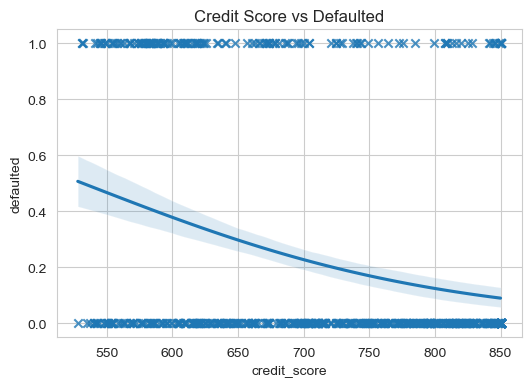

In [156]:
# Plot credit score vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'credit_score', y = 'defaulted', 
                 logistic = True, marker = "x")
ax.set(title = 'Credit Score vs Defaulted')

In [ ]:
credit score has a negative correlation to defaulted

[Text(0.5, 1.0, 'DTI Ratio vs Defaulted')]

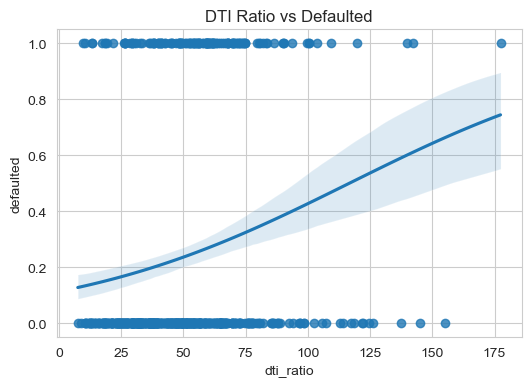

In [151]:
# Plot DTI ratio vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'dti_ratio', y = 'defaulted', logistic = True)
ax.set(title = 'DTI Ratio vs Defaulted')

[Text(0.5, 1.0, 'Loan Amount vs Defaulted')]

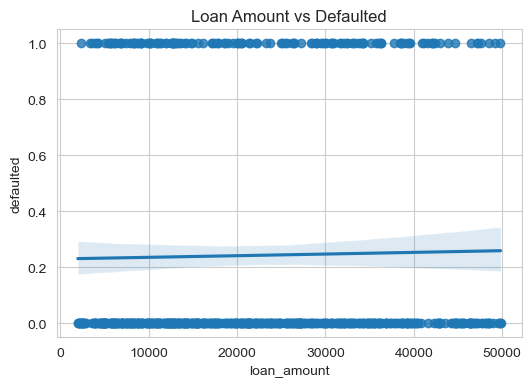

In [150]:
# Plot loan amount vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'loan_amount', y = 'defaulted', logistic = True)
ax.set(title = 'Loan Amount vs Defaulted') 

[Text(0.5, 1.0, 'Interest Rate vs Defaulted')]

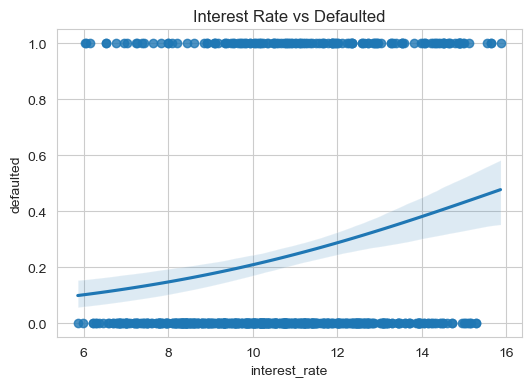

In [149]:
# Plot interest rate vs default and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'interest_rate', y = 'defaulted', logistic = True)
ax.set(title = 'Interest Rate vs Defaulted')

[Text(0.5, 1.0, 'Age vs Defaulted')]

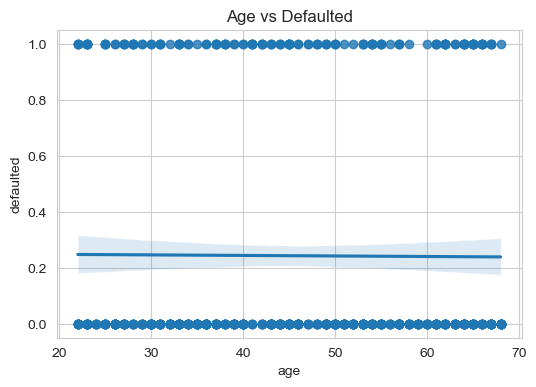

In [148]:
# Plot age vs default and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'age', y = 'defaulted', logistic = True)
ax.set(title = 'Age vs Defaulted')

[Text(0.5, 1.0, 'Years Employed vs Defaulted')]

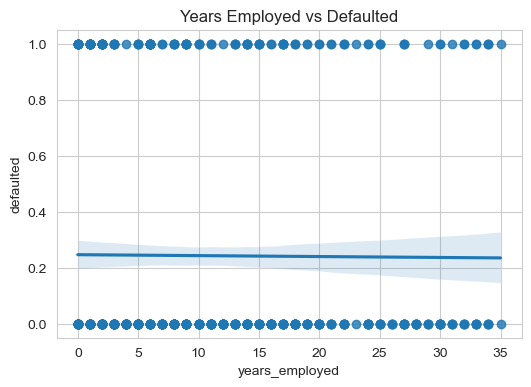

In [147]:
# PLot years employed vs default and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'years_employed', y = 'defaulted', logistic = True)
ax.set(title = 'Years Employed vs Defaulted')

[Text(0.5, 1.0, 'Annual Income vs Defaulted')]

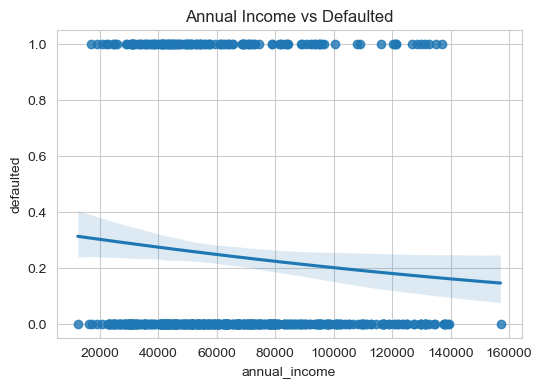

In [146]:
# Plot annual income vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'annual_income', y = 'defaulted', logistic = True)
ax.set(title = 'Annual Income vs Defaulted')

[Text(0.5, 1.0, 'Existing Monthly Debt vs Defaulted')]

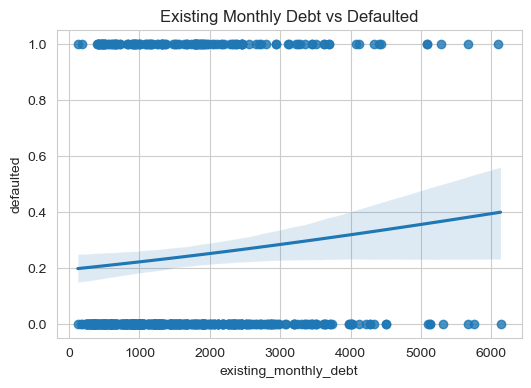

In [145]:
# PLot existing monthly debt vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'existing_monthly_debt', y = 'defaulted', logistic = True)
ax.set(title = 'Existing Monthly Debt vs Defaulted')

[Text(0.5, 1.0, 'Monthly Payment vs Defaulted')]

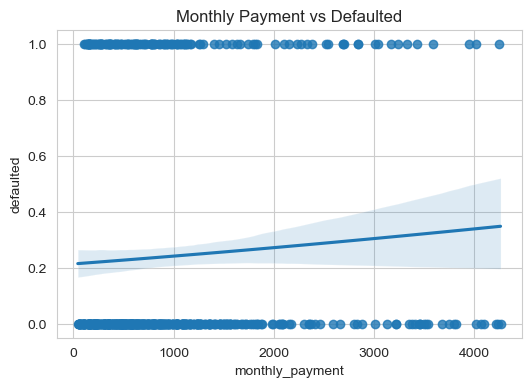

In [144]:
# plot monthly payment vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'monthly_payment', y = 'defaulted', logistic = True)
ax.set(title = 'Monthly Payment vs Defaulted')

In [250]:
myDataNum = myData[numColumns]
myDataNum.corr(method = 'pearson')[['defaulted']].sort_values(by = 'defaulted', ascending = False) # Pearson Correlation (vs Kendall or spearman)

,defaulted
defaulted,1.000000
interest_rate,0.198930
dti_ratio,0.192454
existing_monthly_debt,0.083325
monthly_payment,0.061867
loan_amount,0.018116
age,-0.006085
years_employed,-0.007199
annual_income,-0.081546
credit_score,-0.286394


<Axes: >

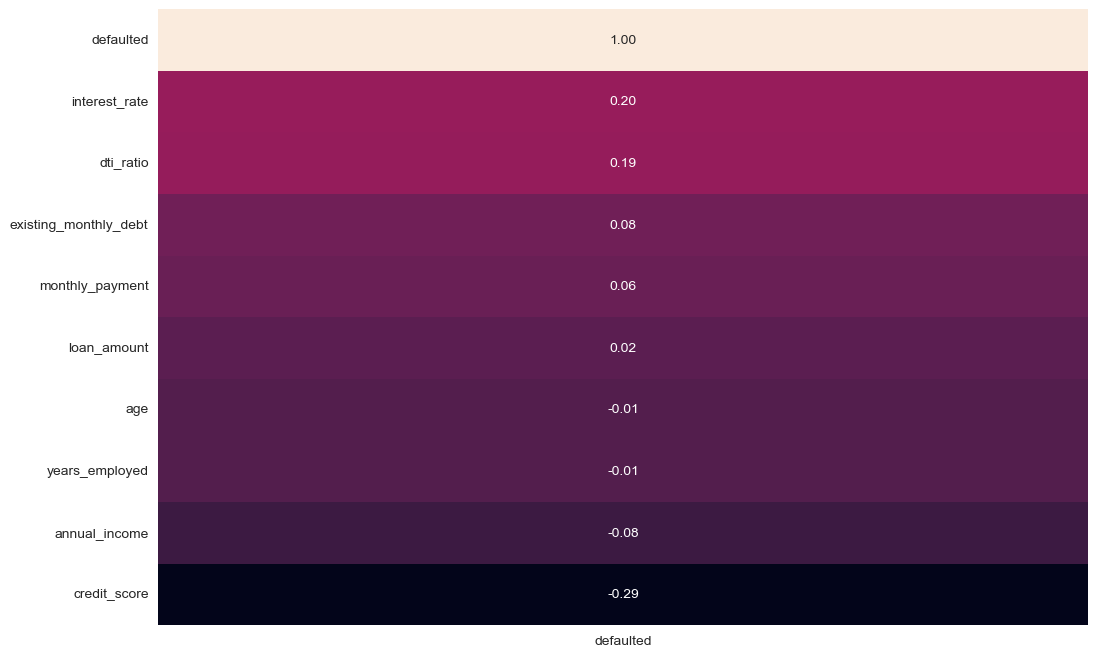

In [278]:
# create heatmap specific to correlation with defaulted
sns.heatmap(data = myDataNum.corr(method = 'pearson')[['defaulted']].sort_values(by = 'defaulted', ascending = False), 
            #cmap = 'Blues', 
            annot = True, cbar = False, fmt = f'.2f')

### Assess correlation on all columns

In [122]:
# move Defaulted column to first column in dataframe
myData = myData.set_index('defaulted').reset_index()

In [127]:
# create copy of data set with all numeric values (converts objects to category codes)
df_numerized = myData.copy()
df_numerized = df_numerized.drop(columns = ['borrower_id', 'loan_id', 
                                            'application_date', 'cred_score_bin', 
                                            'dti_bin', 'yrs_emp_bin',
                                            'int_rate_bin'])
for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype ('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes

df_numerized.head()

,defaulted,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent
0,0,62,4,3,4,6,31020,596,2,1,892,8,16100.0,36,13.05,542.86,55.5,3,0
1,1,62,4,3,4,6,31020,596,2,1,892,5,5600.0,48,14.21,153.62,40.4,1,138
2,0,24,3,3,1,4,40188,543,1,2,869,7,44700.0,36,12.37,1492.59,70.5,3,0
3,1,50,16,1,0,22,41014,611,0,0,1806,0,9200.0,48,11.18,238.58,59.8,1,34
4,0,43,25,3,1,19,35036,701,0,2,928,7,11200.0,36,9.66,359.61,44.1,0,0


In [124]:
df_numerized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   defaulted              601 non-null    int64  
 1   age                    601 non-null    int64  
 2   state                  601 non-null    int8   
 3   education_level        601 non-null    int8   
 4   employment_status      601 non-null    int8   
 5   years_employed         601 non-null    int64  
 6   annual_income          601 non-null    int64  
 7   credit_score           601 non-null    int64  
 8   home_ownership         601 non-null    int8   
 9   dependents             601 non-null    int64  
 10  existing_monthly_debt  601 non-null    int64  
 11  loan_purpose           601 non-null    int8   
 12  loan_amount            601 non-null    float64
 13  term_months            601 non-null    int64  
 14  interest_rate          601 non-null    float64
 15  monthl

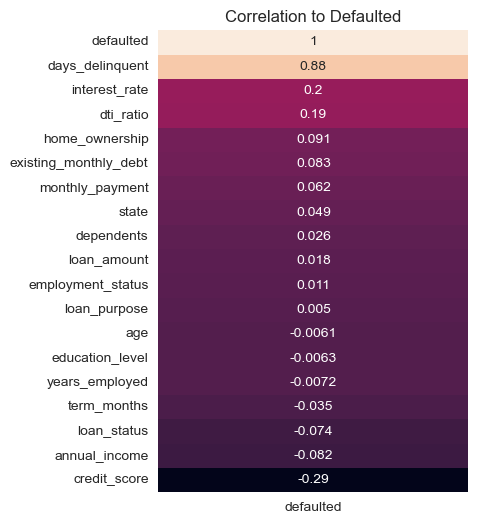

In [141]:
# create heatmap of correlation to defaulted
correlation_defaulted = df_numerized.corr(method = 'pearson')[['defaulted']] \
    .sort_values('defaulted', ascending = False)

fig, ax = plt.subplots(figsize = (4, 6))

ax = sns.heatmap(correlation_defaulted, annot = True, cbar = False)
plt.title('Correlation to Defaulted', loc = 'center')
plt.show()

fig.subplots_adjust(left = 0.5)

ax.get_figure().savefig('corr_all_features.png')

In [301]:
correlation_matrix = df_numerized.corr()
corr_pairs = correlation_matrix.unstack()
corr_pairs.head(20)

defaulted  defaulted                1.000000
           age                     -0.006085
           state                    0.049245
           education_level         -0.006321
           employment_status        0.010721
           years_employed          -0.007199
           annual_income           -0.081546
           credit_score            -0.286394
           home_ownership           0.090763
           dependents               0.026293
           existing_monthly_debt    0.083325
           loan_purpose             0.004983
           loan_amount              0.018116
           term_months             -0.034632
           interest_rate            0.198930
           monthly_payment          0.061867
           dti_ratio                0.192454
           loan_status             -0.074436
           days_delinquent          0.881093
age        defaulted               -0.006085
dtype: float64

In [302]:
sorted_pairs = corr_pairs.sort_values()
sorted_pairs.head(20)

credit_score           interest_rate           -0.755153
interest_rate          credit_score            -0.755153
term_months            monthly_payment         -0.591513
monthly_payment        term_months             -0.591513
term_months            dti_ratio               -0.455627
dti_ratio              term_months             -0.455627
defaulted              credit_score            -0.286394
credit_score           defaulted               -0.286394
                       days_delinquent         -0.266843
days_delinquent        credit_score            -0.266843
dti_ratio              annual_income           -0.206438
annual_income          dti_ratio               -0.206438
employment_status      existing_monthly_debt   -0.135653
existing_monthly_debt  employment_status       -0.135653
years_employed         credit_score            -0.125426
credit_score           years_employed          -0.125426
employment_status      annual_income           -0.123948
annual_income          employme

In [303]:
high_corr = sorted_pairs[(sorted_pairs) > 0.5]
high_corr.head(20)

age                    years_employed           0.528210
years_employed         age                      0.528210
annual_income          existing_monthly_debt    0.617895
existing_monthly_debt  annual_income            0.617895
dti_ratio              monthly_payment          0.665915
monthly_payment        dti_ratio                0.665915
                       loan_amount              0.677752
loan_amount            monthly_payment          0.677752
days_delinquent        defaulted                0.881093
defaulted              days_delinquent          0.881093
                       defaulted                1.000000
dependents             dependents               1.000000
dti_ratio              dti_ratio                1.000000
age                    age                      1.000000
state                  state                    1.000000
education_level        education_level          1.000000
employment_status      employment_status        1.000000
years_employed         years_em

In [306]:
# save points for DFs used in correlation analysis
myDataNum.to_pickle('basicNumDF.pkl')
df_numerized.to_pickle('numerizedDF.pkl')


### Assess default counts over time

In [13]:
defaultedCounts = myData.pivot_table(index = 'application_date', 
                                     values = 'borrower_id',
                                     columns = 'defaulted', 
                                     aggfunc = 'count')
defaultedCounts.head()

defaulted,0,1
application_date,,
2024-01-02,1.0,NaN
2024-01-04,1.0,NaN
2024-01-05,3.0,NaN
2024-01-06,3.0,NaN
2024-01-07,1.0,NaN


<Axes: title={'center': 'Counts by Default Type over Time'}, xlabel='application_date'>

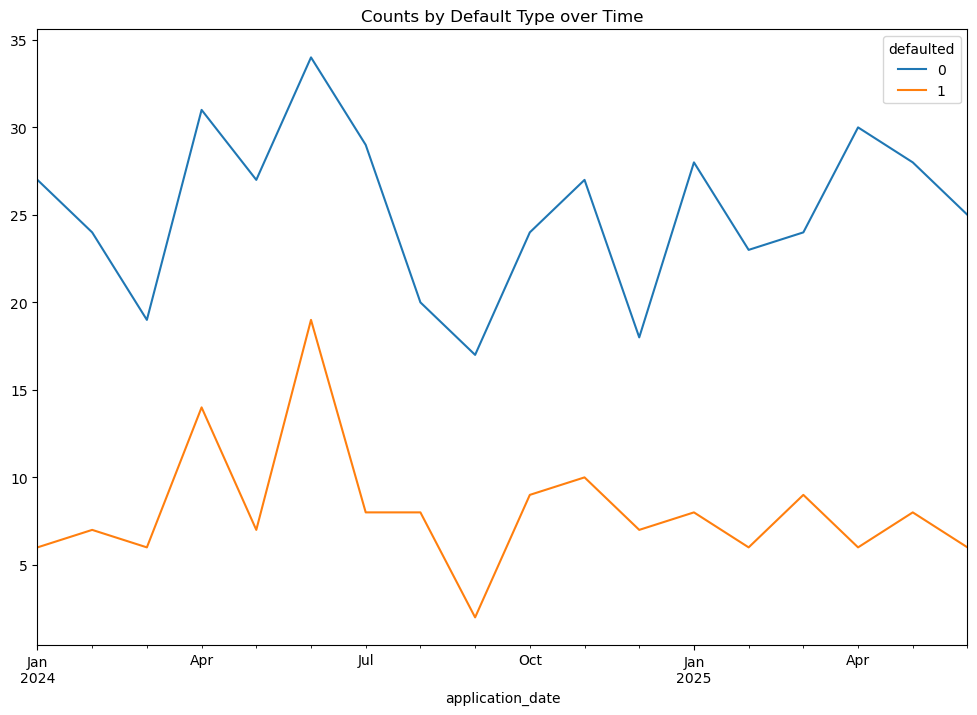

In [17]:
countsByMonth = defaultedCounts.resample(rule = 'ME').sum()
countsByMonth.plot.line(title = 'Counts by Default Type over Time')

In [29]:
# correlation between dti and interest rate per credit score bin

# create copy of data set with all numeric values (converts objects to category codes)
df_numerized_1 = myData.query('cred_score_bin == "520-599"').copy()
df_numerized_1 = df_numerized_1.drop(columns = ['borrower_id', 'loan_id', 'application_date', 'cred_score_bin', 'dti_bin', 'yrs_emp_bin'])
for col_name in df_numerized_1.columns:
    if(df_numerized_1[col_name].dtype == 'object'):
        df_numerized_1[col_name] = df_numerized_1[col_name].astype ('category')
        df_numerized_1[col_name] = df_numerized_1[col_name].cat.codes

#df_numerized.head()

correlation_defaulted = df_numerized_1.query('cred_score_bin == "520-599"').corr(method = 'pearson')[['defaulted']].sort_values('defaulted', ascending = False)
sns.heatmap(correlation_defaulted, annot = True)
plt.title('Correlation to Defaulted for All Features')
plt.show()

KeyError: "['yrs_emp_bin'] not found in axis"

In [27]:
myData.groupby(['cred_score_bin', 'dti_bin', 'int_rate_bin'], observed = False)['defaulted'].mean().unstack()

int_rate_bin            (5.85, 6.86]  (6.86, 7.86]  (7.86, 8.86]  \
cred_score_bin dti_bin                                             
520-599        0-25%             NaN           NaN           NaN   
               26-35%            NaN           NaN           NaN   
               36-45%            NaN           NaN           NaN   
               46-50%            NaN           NaN           NaN   
               >51%              NaN           NaN           NaN   
600-649        0-25%             NaN           NaN           NaN   
               26-35%            NaN           NaN           NaN   
               36-45%            NaN           NaN           NaN   
               46-50%            NaN           NaN           NaN   
               >51%              NaN           NaN           NaN   
650-699        0-25%             NaN           NaN      0.000000   
               26-35%            NaN           NaN      0.000000   
               36-45%            NaN           NaN      0.500000   
               46-50%            NaN           NaN           NaN   
               >51%              NaN           NaN           NaN   
700-749        0-25%             NaN           NaN      0.000000   
               26-35%            NaN           0.0           NaN   
               36-45%            NaN           NaN      0.250000   
               46-50%            NaN           0.0      0.000000   
               >51%              NaN           0.5      0.250000   
750+           0-25%        0.000000           0.0      0.000000   
               26-35%       0.666667           0.2      0.000000   
               36-45%       0.200000           0.2      0.166667   
               46-50%       0.333333           0.0      0.166667   
               >51%         0.166667           0.2      0.083333   

int_rate_bin            (8.86, 9.86]  (9.86, 10.86]  (10.86, 11.86]  \
cred_score_bin dti_bin                                                
520-599        0-25%             NaN       0.500000             NaN   
               26-35%            NaN       0.000000        0.000000   
               36-45%            NaN            NaN        0.250000   
               46-50%            NaN            NaN        0.000000   
               >51%              NaN       0.666667        0.500000   
600-649        0-25%             NaN       0.500000        0.000000   
               26-35%       0.000000       0.000000        0.000000   
               36-45%            NaN       0.285714        1.000000   
               46-50%            NaN       0.250000        0.000000   
               >51%         0.000000       0.333333        0.500000   
650-699        0-25%        0.666667       0.000000             NaN   
               26-35%       0.000000       0.250000        0.000000   
               36-45%       0.666667       0.000000             NaN   
               46-50%       1.000000       0.166667        0.000000   
               >51%         0.444444       0.250000        0.800000   
700-749        0-25%        0.000000       0.500000             NaN   
               26-35%       0.200000       0.000000        0.000000   
               36-45%       0.333333       0.250000        0.000000   
               46-50%       0.000000       0.000000        0.000000   
               >51%         0.333333       0.428571        0.142857   
750+           0-25%        0.428571       0.000000        0.000000   
               26-35%       0.000000       0.000000        0.000000   
               36-45%       0.000000       0.000000        0.333333   
               46-50%       0.000000       0.142857        0.000000   
               >51%         0.187500       0.142857        0.000000   

int_rate_bin            (11.86, 12.86]  (12.86, 13.86]  (13.86, 14.86]  \
cred_score_bin dti_bin                                                   
520-599        0-25%          0.000000             NaN        0.000000   
               26-35%  

# write a summary of top 3 risk factors and suggest specific thresholds (min cred score or max DTI) for the underwriting team